# Stage 03 — Feature Engineering

**Owner:** Aadarsh Ghimire (Preprocessing & Research Design Lead)

**Objective.** Produce the modelling-ready artefacts:
- `y_reg` — continuous target `prop_women_mgmt` (RQ1 regression).
- `y_cls` — binary target `women_mgmt_high` split at the median of `prop_women_mgmt` (RQ2 classification).
- `X` — encoded feature matrix (ordinal `employer_size`, one-hot `anzsic_division`, binary policies, optional ABS numeric).

**Inputs.** `data/processed/checkpoints/02_master.parquet`

**Outputs.**
- `data/processed/checkpoints/03_master_with_targets.parquet`
- `data/processed/checkpoints/03_X.parquet`, `03_y_reg.parquet`, `03_y_cls.parquet`
- `data/processed/checkpoints/03_feature_names.json`

## 1. Setup and load master table

In [1]:
import sys, json
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from src import config, feature_engineering

pd.set_option("display.max_columns", 30)

master_path = config.CHECKPOINT_DIR / "02_master.parquet"
master = pd.read_parquet(master_path) if master_path.exists() else pd.read_csv(master_path.with_suffix('.csv'))
print("Master loaded:", master.shape)

Master loaded: (8239, 17)


## 2. Compute targets

- `prop_women_overall = women_total / (women_total + men_total)`
- `prop_women_mgmt    = women_mgmt  / (women_mgmt  + men_mgmt)`
- `women_mgmt_high` = 1 if `prop_women_mgmt` exceeds its median, 0 otherwise (balanced binary target as per Assessment 1 §4.3).

In [2]:
master = feature_engineering.compute_targets(master)
cols = ["employer_size", "anzsic_division", "women_total", "men_total",
        "women_mgmt", "men_mgmt", "prop_women_overall", "prop_women_mgmt",
        "women_mgmt_high"]
master[cols].head(10)

20:39:27 | INFO    | src.feature_engineering | RQ2 median split at prop_women_mgmt=0.400 (High vs Low)


,employer_size,anzsic_division,women_total,men_total,women_mgmt,men_mgmt,prop_women_overall,prop_women_mgmt,women_mgmt_high
0,<250,"Professional, Scientific and Technical Services",32,71,7.0,23.0,0.310680,0.233333,0
1,0,"Transport, Postal and Warehousing",79,52,0.0,10.0,0.603053,0.000000,0
2,<250,Wholesale Trade,60,60,17.0,25.0,0.500000,0.404762,1
3,<250,"Professional, Scientific and Technical Services",30,97,7.0,29.0,0.236220,0.194444,0
4,250-499,Accommodation and Food Services,131,128,8.0,20.0,0.505792,0.285714,0
5,250-499,Mining,35,225,1.0,9.0,0.134615,0.100000,0
6,<250,Administrative and Support Services,33,191,1.0,10.0,0.147321,0.090909,0
7,<250,Administrative and Support Services,44,65,11.0,11.0,0.403670,0.500000,1
8,<250,"Professional, Scientific and Technical Services",108,39,28.0,14.0,0.734694,0.666667,1
9,<250,Health Care and Social Assistance,121,30,15.0,8.0,0.801325,0.652174,1


In [3]:
print("prop_women_mgmt — summary:")
print(master["prop_women_mgmt"].describe())
print("\nprop_women_overall — summary:")
print(master["prop_women_overall"].describe())
print("\nwomen_mgmt_high class balance:")
print(master["women_mgmt_high"].value_counts(dropna=False))

prop_women_mgmt — summary:
count    7971.000000
mean        0.415811
std         0.250520
min         0.000000
25%         0.209673
50%         0.400000
75%         0.600000
max         1.000000
Name: prop_women_mgmt, dtype: float64

prop_women_overall — summary:
count    8239.000000
mean        0.471230
std         0.246052
min         0.000000
25%         0.251761
50%         0.474719
75%         0.678308
max         1.000000
Name: prop_women_overall, dtype: float64

women_mgmt_high class balance:
women_mgmt_high
0    4278
1    3961
Name: count, dtype: Int64


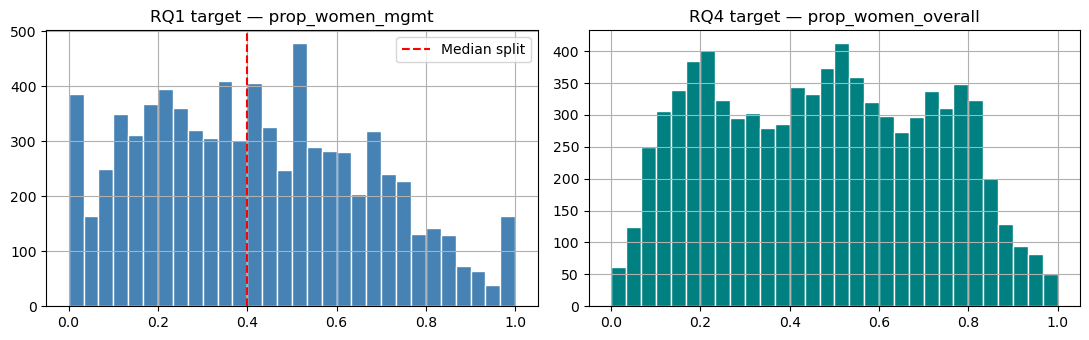

In [4]:
# Target distributions (visual sanity check)
fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))
master["prop_women_mgmt"].dropna().hist(bins=30, ax=axes[0], color="steelblue", edgecolor="white")
axes[0].axvline(master["prop_women_mgmt"].median(), color="red", linestyle="--", label="Median split")
axes[0].set_title("RQ1 target — prop_women_mgmt")
axes[0].legend()

master["prop_women_overall"].dropna().hist(bins=30, ax=axes[1], color="teal", edgecolor="white")
axes[1].set_title("RQ4 target — prop_women_overall")
plt.tight_layout(); plt.show()

## 3. Encode features

- **Ordinal encode** `employer_size` — size bands have a natural order (`<250` < `250-499` < ...). Encoded via `EMPLOYER_SIZE_ORDER` in config.
- **One-hot encode** `anzsic_division` — divisions are nominal (no order). `drop_first=True` to avoid the dummy-variable trap.
- **Keep binary** policy flags as 0/1.

In [5]:
X, y_reg, y_cls, feature_names = feature_engineering.encode_features(master)
print("X shape    :", X.shape)
print("y_reg size :", len(y_reg))
print("y_cls size :", len(y_cls), "| positive rate:", float(y_cls.mean()))
X.head()

20:39:28 | WARNING | src.feature_engineering | Unknown employer_size values set to -1: ['0']
20:39:28 | INFO    | src.feature_engineering | Encoded X: shape=(7971, 24); y_reg=7971; y_cls pos rate=0.50
X shape    : (7971, 24)
y_reg size : 7971
y_cls size : 7971 | positive rate: 0.49692635804792373


,employer_size_ord,has_formal_dni_policy,took_action_on_pay_gap,has_employer_paid_parental_leave,has_domestic_violence_policy,offers_flexible_work,div_Administrative and Support Services,"div_Agriculture, Forestry and Fishing",div_Arts and Recreation Services,div_Construction,div_Education and Training,"div_Electricity, Gas, Water and Waste Services",div_Financial and Insurance Services,div_Health Care and Social Assistance,div_Information Media and Telecommunications,div_Manufacturing,div_Mining,div_Other Services,"div_Professional, Scientific and Technical Services",div_Public Administration and Safety,"div_Rental, Hiring and Real Estate Services",div_Retail Trade,"div_Transport, Postal and Warehousing",div_Wholesale Trade
0,0,0,1,0,1,1,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0
1,-1,1,1,0,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0
2,0,0,0,1,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1
3,0,1,1,1,1,1,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0
4,1,1,1,1,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


In [6]:
# Feature-name inventory by group
groups = {
    "ordinal_size": [c for c in X.columns if c == "employer_size_ord"],
    "policy_flags": [c for c in X.columns if c.startswith(("has_", "offers_", "took_"))],
    "industry_dummies": [c for c in X.columns if c.startswith("div_")]
}
for g, cols in groups.items():
    print(f"{g:20s} ({len(cols)}): {cols}")

ordinal_size         (1): ['employer_size_ord']
policy_flags         (5): ['has_formal_dni_policy', 'took_action_on_pay_gap', 'has_employer_paid_parental_leave', 'has_domestic_violence_policy', 'offers_flexible_work']
industry_dummies     (18): ['div_Administrative and Support Services', 'div_Agriculture, Forestry and Fishing', 'div_Arts and Recreation Services', 'div_Construction', 'div_Education and Training', 'div_Electricity, Gas, Water and Waste Services', 'div_Financial and Insurance Services', 'div_Health Care and Social Assistance', 'div_Information Media and Telecommunications', 'div_Manufacturing', 'div_Mining', 'div_Other Services', 'div_Professional, Scientific and Technical Services', 'div_Public Administration and Safety', 'div_Rental, Hiring and Real Estate Services', 'div_Retail Trade', 'div_Transport, Postal and Warehousing', 'div_Wholesale Trade']


## 4. Checkpoint

In [7]:
def save_df(df, name):
    p = config.CHECKPOINT_DIR / name
    try:
        df.to_frame().to_parquet(p) if isinstance(df, pd.Series) else df.to_parquet(p)
    except Exception:
        df.to_csv(p.with_suffix(".csv"), index=False)
        p = p.with_suffix(".csv")
    return p

# Dropping rows with missing y_reg occurred inside encode_features; master_with_targets
# still contains every employer so EDA can use the full population.
paths = {
    "master": save_df(master, "03_master_with_targets.parquet"),
    "X": save_df(X, "03_X.parquet"),
    "y_reg": save_df(y_reg.rename("prop_women_mgmt"), "03_y_reg.parquet"),
    "y_cls": save_df(y_cls.astype('Int64').rename("women_mgmt_high"), "03_y_cls.parquet"),
}
with open(config.CHECKPOINT_DIR / "03_feature_names.json", "w") as f:
    json.dump(feature_names, f, indent=2)
paths["feature_names"] = config.CHECKPOINT_DIR / "03_feature_names.json"

for k, p in paths.items():
    print(f"{k:15s} → {p}")

master          → D:\CDU\Semester3\PRT564_DATA_ANALYTICS_AND_VISUALISATION\project\data\processed\checkpoints\03_master_with_targets.parquet
X               → D:\CDU\Semester3\PRT564_DATA_ANALYTICS_AND_VISUALISATION\project\data\processed\checkpoints\03_X.parquet
y_reg           → D:\CDU\Semester3\PRT564_DATA_ANALYTICS_AND_VISUALISATION\project\data\processed\checkpoints\03_y_reg.parquet
y_cls           → D:\CDU\Semester3\PRT564_DATA_ANALYTICS_AND_VISUALISATION\project\data\processed\checkpoints\03_y_cls.parquet
feature_names   → D:\CDU\Semester3\PRT564_DATA_ANALYTICS_AND_VISUALISATION\project\data\processed\checkpoints\03_feature_names.json


## Summary

- Two continuous targets computed and sanity-checked.
- Binary target created via median split — balanced by construction.
- Encoded `X` ready for scikit-learn; feature names grouped by meaning.

**Next:** `04_eda.ipynb` — the visual story that will drive the presentation.